# Poster Figure Exports

This notebook exports the OCEANS 2026 Monterey poster panels at poster print
resolution. It is a presentation-layer notebook: every number it draws comes
from the same uncertainty product notebook `6` builds, and every color mapping
is the notebook `6` mapping.

What changes here is placement, not content. The poster panels drop the
in-figure title, move the colorbar to a horizontal bar beneath the map, add a
lettered caption, and label the support contours inline instead of in a legend
box. The panels are exported both individually and as a single three-across
row matching the poster's decomposition block.

| Panel | Export stem | Notebook `6` chart |
| --- | --- | --- |
| (a) | `poster_a_sound_speed_teos10_110m` | `sound_speed_teos10_110m` |
| (b) | `poster_b_w_raw_110m` | `w_raw_110m` |
| (c) | `poster_c_sound_speed_teos10_w_contours_110m` | `sound_speed_teos10_w_contours_110m` |

Like the other notebooks in this folder, this one runs independently. It
reuses the local `data/` caches when they are present and valid, and rebuilds
the cycle models, spatial variance bucket, and uncertainty product from source
when they are not.

In [1]:
from __future__ import annotations

import pickle
import sys
from itertools import product
from pathlib import Path

import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import cartopy
from tqdm.auto import tqdm

from argo_kwsi.uncertainty import (
    GaussianScale,
    SoundSpeedUncertaintyProduct,
    SoundSpeedUncertaintyConfig,
    WeightConfig,
    estimate_depthwise_spatial_variance as estimate_depthwise_spatial_variance_package,
)
from argo_kwsi.cycle.config import ModelSettings

## Configuration

The domain, grid, target depths, anchor date, and weighting configuration are
the notebook `6` configuration. They are repeated here rather than imported so
this notebook can rebuild the product on its own, and so a divergence from
notebook `6` would show up as an explicit edit rather than a silent one.

In [2]:
notebook_dir = Path.cwd()
if not (notebook_dir / "lib").exists():
    notebook_dir = Path("research/underwater-acoustics/notebooks")

data_path = notebook_dir / "data"
chart_path = data_path / "charts" / "poster"
cartopy_data_path = data_path / "cartopy"
data_path.mkdir(exist_ok=True, parents=True)
chart_path.mkdir(exist_ok=True, parents=True)
cartopy_data_path.mkdir(exist_ok=True, parents=True)
cartopy.config["data_dir"] = str(cartopy_data_path)

if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from lib.plotting import (
    add_poster_colorbar,
    add_poster_contours,
    draw_poster_matrix,
    draw_poster_support_matrix,
    poster_panel_grid,
    poster_raw_support_tick_formatter,
    save_figure,
    set_poster_caption,
    support_region_cmap,
)
from lib.product_support import (
    build_cycle_models,
    cache_metadata_matches,
    load_filtered_argo_data,
    write_cache_metadata,
)

box = [
    80,
    99,
    6,
    23,
    0,
    750,
    "2011-01-01",
    "2020-12-31",
]

target_pressure = np.array([5.0, 35.0, 110.0, 500.0])
anchor_time = np.datetime64("2015-07-01")

lat_resolution = 1e-1
lon_resolution = 1e-1
lat_array = np.arange(box[2], box[3] + lat_resolution, lat_resolution)
lon_array = np.arange(box[0], box[1] + lon_resolution, lon_resolution)
lat_lon_product = list(product(lat_array, lon_array))

distance_kernel_sigma_deg = 1.0 / 3.0
candidate_radius_sigma = 3.0
dist_rad = distance_kernel_sigma_deg * candidate_radius_sigma

seconds_per_year = 365.25 * 24 * 60 * 60
seconds_per_week = 7 * 24 * 60 * 60

year_stdev = 3.0
season_weeks = 8
season_week_stdev = 3.0

use_distance_weight = True
use_time_weight = True
use_season_weight = True
sensor_support_tau = 40.0

weight_config = WeightConfig(
    distance=GaussianScale(distance_kernel_sigma_deg),
    time=GaussianScale(year_stdev * seconds_per_year),
    season=GaussianScale.from_border(season_weeks * seconds_per_week, season_week_stdev),
    use_distance=use_distance_weight,
    use_time=use_time_weight,
    use_season=use_season_weight,
)

uncertainty_config = SoundSpeedUncertaintyConfig(
    target_pressure=target_pressure,
    weight_config=weight_config,
    anchor_time=anchor_time,
    candidate_radius=dist_rad,
    distance_metric="planar_degrees",
    sensor_support_tau=sensor_support_tau,
)

weighting_cache_metadata = {
    "anchor_time": str(anchor_time),
    "distance_kernel_sigma_deg": distance_kernel_sigma_deg,
    "candidate_radius_sigma": candidate_radius_sigma,
    "dist_rad": dist_rad,
    "year_stdev": year_stdev,
    "season_weeks": season_weeks,
    "season_week_stdev": season_week_stdev,
    "use_distance_weight": use_distance_weight,
    "use_time_weight": use_time_weight,
    "use_season_weight": use_season_weight,
    "sensor_support_tau": sensor_support_tau,
}

argo_data_path = data_path / "argo_data.pkl"
cycle_model_cache_path = data_path / "pchip_cycle_models.pkl"
spatial_variance_path = data_path / "sound_speed_uncertainty_spatial_variance.pkl"
spatial_variance_metadata_path = data_path / "sound_speed_uncertainty_spatial_variance_metadata.json"
uncertainty_product_path = data_path / "sound_speed_uncertainty_product.pkl"
uncertainty_product_metadata_path = data_path / "sound_speed_uncertainty_product_metadata.json"

## Load or Rebuild the Uncertainty Product

The cached product is used only when its recorded weighting metadata matches
the configuration above. Any mismatch forces a rebuild rather than silently
plotting a product built under different settings.

In [3]:
uncertainty_product_cache_valid = uncertainty_product_path.exists() and cache_metadata_matches(
    uncertainty_product_metadata_path,
    weighting_cache_metadata,
)

if uncertainty_product_cache_valid:
    uncertainty_product = pd.read_pickle(uncertainty_product_path)
    product_source = "cached product"
else:
    settings = ModelSettings(n_folds=5)
    if cycle_model_cache_path.exists():
        with cycle_model_cache_path.open("rb") as f:
            cycle_model_bundle = pickle.load(f)
        cycle_models = cycle_model_bundle["cycle_models"]
    else:
        ds = load_filtered_argo_data(argo_data_path, box)
        cycle_models, models_data = build_cycle_models(ds, settings)
        with cycle_model_cache_path.open("wb") as f:
            pickle.dump({"cycle_models": cycle_models, "models_data": models_data}, f)

    spatial_variance_cache_valid = spatial_variance_path.exists() and cache_metadata_matches(
        spatial_variance_metadata_path,
        weighting_cache_metadata,
    )
    if spatial_variance_cache_valid:
        with spatial_variance_path.open("rb") as f:
            spatial_variance = pickle.load(f)
    else:
        spatial_variance = estimate_depthwise_spatial_variance_package(
            cycle_models=cycle_models,
            config=uncertainty_config,
        )
        with spatial_variance_path.open("wb") as f:
            pickle.dump(spatial_variance, f)
        write_cache_metadata(spatial_variance_metadata_path, weighting_cache_metadata)

    uncertainty_product_builder = SoundSpeedUncertaintyProduct(
        cycle_models=cycle_models,
        spatial_variance=spatial_variance,
        config=uncertainty_config,
    )
    records = []
    for lat, lon in tqdm(lat_lon_product):
        records.extend(
            uncertainty_product_builder.query(latitude=lat, longitude=lon).to_dict("records")
        )
    uncertainty_product = pd.DataFrame.from_records(records)
    uncertainty_product.to_pickle(uncertainty_product_path)
    write_cache_metadata(uncertainty_product_metadata_path, weighting_cache_metadata)
    product_source = "rebuilt product"

uncertainty_product_110m = uncertainty_product.loc[
    np.isclose(uncertainty_product["depth_m"], 110.0)
].copy()

{
    "product_source": product_source,
    "product_rows": len(uncertainty_product),
    "rows_at_110m": len(uncertainty_product_110m),
}

{'product_source': 'cached product',
 'product_rows': 92308,
 'rows_at_110m': 23077}

## Figure-Ready 110 m Matrices

Same pivots as notebook `6`, restricted to the fields the three poster panels
need.

In [4]:
chart_latitudes = pd.Index(lat_array, name="latitude")
chart_longitudes = pd.Index(lon_array, name="longitude")

figure_matrices_110m = {
    field: uncertainty_product_110m.pivot(index="latitude", columns="longitude", values=field).reindex(
        index=chart_latitudes,
        columns=chart_longitudes,
    )
    for field in ["sound_speed_teos10", "W_raw"]
}

sound_speed_110m = figure_matrices_110m["sound_speed_teos10"]
support_raw_110m = figure_matrices_110m["W_raw"]

sound_speed_110m.shape, support_raw_110m.shape

((171, 191), (171, 191))

## Shared Chart Parameters

These are the notebook `6` chart parameters, reproduced without change: the
same sound-speed hue ramp, the same `p01..p99` value limits, the same raw
support log normalization with its `W=1 / 6 / 30 / max` breaks and region
color anchors, and the same `W=6` and `W=30` contour levels. Reproducing them
here is what keeps the poster panels the same charts as the notebook `6`
exports rather than a lookalike.

In [5]:
heatmap_interpolation = "bilinear"

support_transparent_threshold = 0.0
support_raw_finite_values = support_raw_110m.to_numpy(dtype=float)
support_raw_finite_values = support_raw_finite_values[np.isfinite(support_raw_finite_values)]
support_raw_log_floor = 1.0
support_raw_vmax = float(np.nanmax(support_raw_finite_values))
support_raw_breaks = [support_raw_log_floor, 6.0, 30.0, support_raw_vmax]
support_cluster_anchors = [
    np.sqrt(support_raw_breaks[0] * support_raw_breaks[1]),
    np.sqrt(support_raw_breaks[1] * support_raw_breaks[2]),
    np.sqrt(support_raw_breaks[2] * support_raw_breaks[3]),
]
support_norm = mcolors.LogNorm(vmin=support_raw_log_floor, vmax=support_raw_vmax)
support_raw_anchor_positions = [float(support_norm(value)) for value in support_cluster_anchors]
support_cmap = support_region_cmap(
    low_anchor=support_raw_anchor_positions[0],
    mid_anchor=support_raw_anchor_positions[1],
    high_anchor=support_raw_anchor_positions[2],
)
support_contour_levels = [6.0, 30.0]
support_contour_labels = ["Low/Mid boundary (W=6)", "Mid/High boundary (W=30)"]

sound_speed_contour_cmap = mcolors.LinearSegmentedColormap.from_list(
    "sound_speed_contour_hue",
    ["#3056ff", "#00c4df", "#19e967", "#e7ea19", "#ff9700", "#ff2b2b"],
)
sound_speed_limits = (
    float(np.nanquantile(sound_speed_110m.to_numpy(dtype=float), 0.01)),
    float(np.nanquantile(sound_speed_110m.to_numpy(dtype=float), 0.99)),
)

sound_speed_cbar_label = "Sound speed (m/s)"
support_cbar_label = r"$W_{\mathrm{raw}}$"

panel_captions = {
    "a": "(a) Estimated sound speed\nat 110 m (m/s)",
    "b": "(b) Observational support\n" + support_cbar_label + " (unitless)",
    "c": "(c) Sound speed with\nsupport contours",
}

poster_dpi = 600

{
    "sound_speed_limits": sound_speed_limits,
    "support_raw_breaks": support_raw_breaks,
    "support_contour_levels": support_contour_levels,
}

{'sound_speed_limits': (1515.5140465510422, 1540.164949750784),
 'support_raw_breaks': [1.0, 6.0, 30.0, 114.36275422530817],
 'support_contour_levels': [6.0, 30.0]}

## Panel Draw Functions

Each panel is drawn by a function taking a map axes and a colorbar axes, so
the same drawing code produces both the standalone exports and the combined
row. The three functions are the only place panel content is defined.

In [6]:
def draw_panel_a(fig, ax, cax, *, caption: bool = True):
    image = draw_poster_matrix(
        ax,
        sound_speed_110m,
        box=box,
        cmap=sound_speed_contour_cmap,
        interpolation=heatmap_interpolation,
        vmin=sound_speed_limits[0],
        vmax=sound_speed_limits[1],
    )
    add_poster_colorbar(fig, cax, image, label=sound_speed_cbar_label)
    if caption:
        set_poster_caption(ax, panel_captions["a"])
    return image


def draw_panel_b(fig, ax, cax, *, caption: bool = True):
    scalar_mappable = draw_poster_support_matrix(
        ax,
        support_raw_110m,
        box=box,
        cmap=support_cmap,
        norm=support_norm,
        transparent_threshold=support_transparent_threshold,
        interpolation="nearest",
        grid_alpha=1.0,
    )
    add_poster_contours(
        ax,
        support_raw_110m,
        contour_levels=support_contour_levels,
        contour_labels=support_contour_labels,
        contour_value_label="W raw",
        contour_value_precision=2,
    )
    add_poster_colorbar(
        fig,
        cax,
        scalar_mappable,
        label=support_cbar_label,
        ticks=support_raw_breaks,
        scale="log",
        tick_formatter=poster_raw_support_tick_formatter(),
    )
    if caption:
        set_poster_caption(ax, panel_captions["b"])
    return scalar_mappable


def draw_panel_c(fig, ax, cax, *, caption: bool = True):
    image = draw_poster_matrix(
        ax,
        sound_speed_110m,
        box=box,
        cmap=sound_speed_contour_cmap,
        interpolation=heatmap_interpolation,
        vmin=sound_speed_limits[0],
        vmax=sound_speed_limits[1],
    )
    add_poster_contours(
        ax,
        support_raw_110m,
        contour_levels=support_contour_levels,
        contour_labels=support_contour_labels,
        contour_value_label="W raw",
        contour_value_precision=2,
    )
    add_poster_colorbar(fig, cax, image, label=sound_speed_cbar_label)
    if caption:
        set_poster_caption(ax, panel_captions["c"])
    return image


panel_draw_functions = {
    "poster_a_sound_speed_teos10_110m": draw_panel_a,
    "poster_b_w_raw_110m": draw_panel_b,
    "poster_c_sound_speed_teos10_w_contours_110m": draw_panel_c,
}

## Standalone Panel Exports

One PNG per panel at 600 dpi, each self-contained with its own caption and
colorbar, for placing the panels individually in the poster layout.

{'poster_a_sound_speed_teos10_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster/poster_a_sound_speed_teos10_110m.png')},
 'poster_b_w_raw_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster/poster_b_w_raw_110m.png')},
 'poster_c_sound_speed_teos10_w_contours_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster/poster_c_sound_speed_teos10_w_contours_110m.png')}}

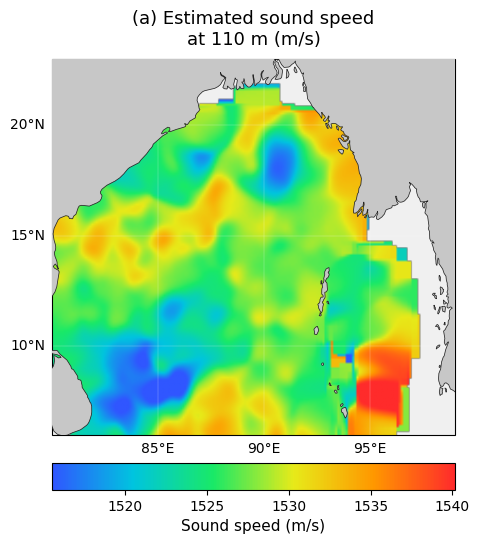

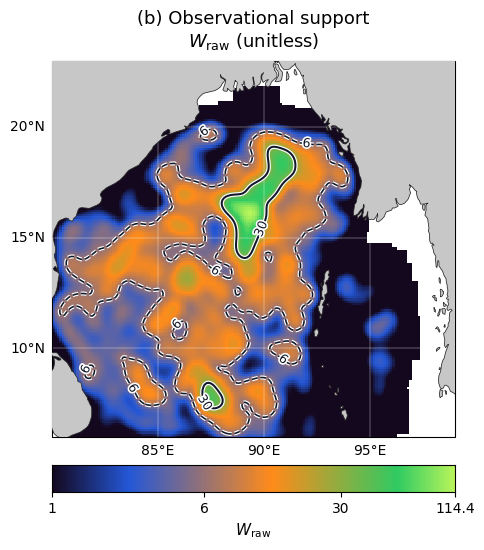

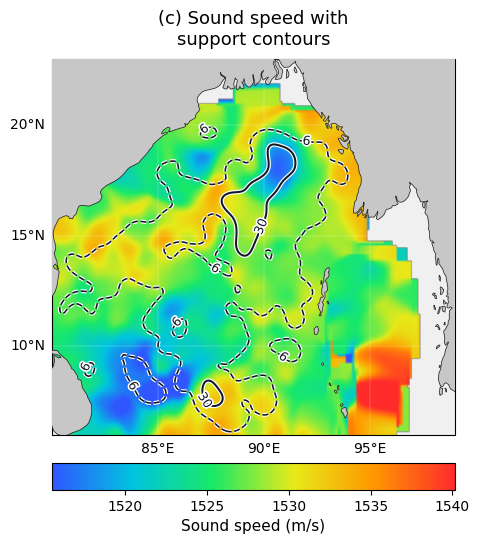

In [7]:
poster_exports = {}

for stem, draw_panel in panel_draw_functions.items():
    fig, map_axes, cbar_axes = poster_panel_grid(1)
    draw_panel(fig, map_axes[0], cbar_axes[0])
    poster_exports[stem] = save_figure(
        fig,
        chart_path=chart_path,
        stem=stem,
        dpi=poster_dpi,
        formats=("png",),
    )

poster_exports

## Combined Three-Across Row

The same three panels in the poster's decomposition-block arrangement, as one
figure, so the row can be placed as a single image if that is easier than
aligning three separately.

{'png': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster/poster_row_110m_decomposition.png')}

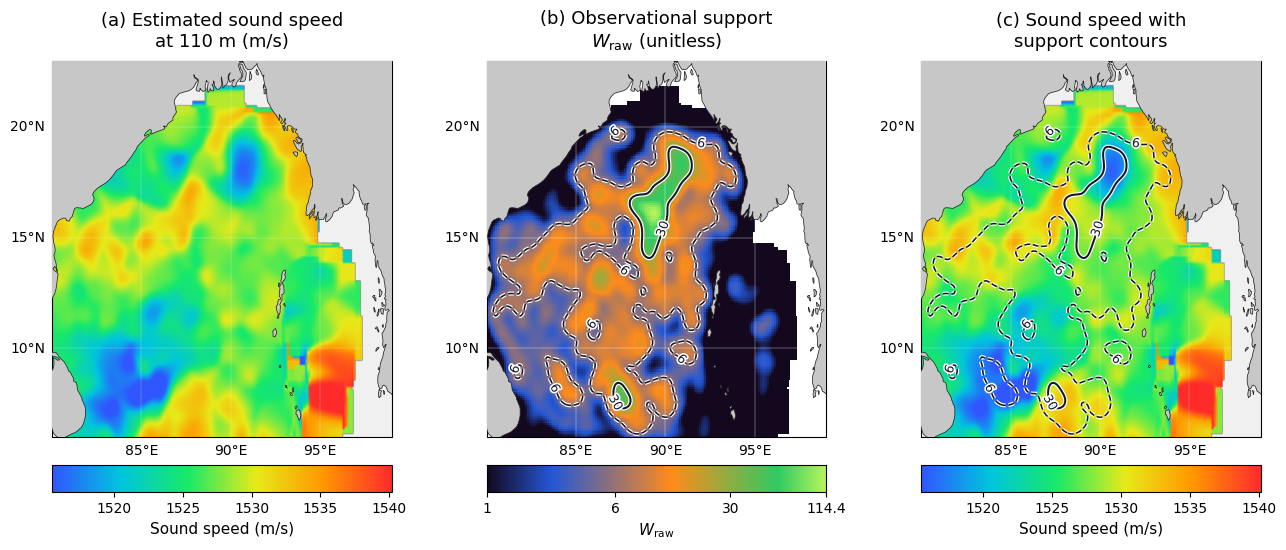

In [8]:
fig, map_axes, cbar_axes = poster_panel_grid(3)
for (stem, draw_panel), ax, cax in zip(panel_draw_functions.items(), map_axes, cbar_axes):
    draw_panel(fig, ax, cax)

poster_exports["poster_row_110m_decomposition"] = save_figure(
    fig,
    chart_path=chart_path,
    stem="poster_row_110m_decomposition",
    dpi=poster_dpi,
    formats=("png",),
)

poster_exports["poster_row_110m_decomposition"]

## Output Paths

In [9]:
{
    "chart_path": chart_path,
    "poster_dpi": poster_dpi,
    "product_source": product_source,
    "poster_exports": poster_exports,
}

{'chart_path': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster'),
 'poster_dpi': 600,
 'product_source': 'cached product',
 'poster_exports': {'poster_a_sound_speed_teos10_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster/poster_a_sound_speed_teos10_110m.png')},
  'poster_b_w_raw_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster/poster_b_w_raw_110m.png')},
  'poster_c_sound_speed_teos10_w_contours_110m': {'png': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster/poster_c_sound_speed_teos10_w_contours_110m.png')},
  'poster_row_110m_decomposition': {'png': PosixPath('/home/jcherry/Documents/git/argo-kwsi/research/underwater-acoustics/notebooks/data/charts/poster/poster_row_110m_decomposition.png')}}}